# Accuracy analysis (R4) across candidate models

Derives classification accuracy from the accuracy runs in `results/<model>/accuracy/run<N>/`
and compares the candidate models against requirement **R4**:

- overall accuracy ≥ 80% (≥ 120/150 golden tickets correct)
- recall ≥ 70% in every category (as counts, rounded up)
- `unclassified` ≤ 2% (≤ 3/150)

Models are listed in `MODELS` below. A model with no run folder yet is shown as **pending**, so
the notebook can be re-run as results arrive; nothing else needs changing.

**Where predictions come from, per run** (best available first):

1. `service.jsonl`: the service log copied in by `sut_collect.ps1` (evidence of record)
2. the matching file in `logs/`, found from `sut_start.json`, if `sut_collect.ps1` has not been run yet
3. `responses.csv`: what `send_golden.py` received (category and client latency only)

Each golden ticket is matched by request id `golden-<row>`. Scoring helpers and thresholds are
imported from `accuracy/score_accuracy.py`, so the numbers agree with its `report.md`.

To add a model's results (on the SUT):

```powershell
.\loadtest\sut_prepare.ps1 -Model qwen3.8:27b -Api chat -Test accuracy -Run 1
python accuracy\send_golden.py --model qwen3.8:27b --run 1
.\loadtest\sut_collect.ps1 -Model qwen3.8:27b -Test accuracy -Run 1
```

If the results come from another machine, copy its `results/<model>/accuracy/run<N>/` folder into
`results/` here and re-run this notebook.

In [1]:
import glob
import json
import math
import os
import re
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "test_and_measure" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "accuracy"))
from score_accuracy import (  # noqa: E402  same thresholds and helpers as the scoring script
    CATEGORIES, GOLDEN, NO_RESPONSE, OVERALL_MIN, RECALL_MIN, UNCLASSIFIED, UNCLASSIFIED_MAX,
    nearest_rank, wilson,
)

# Candidate models: Ollama tag -> endpoint used by the service (OLLAMA_API)
MODELS = {
    "tev1:4b": "systemone",
    "qwen3.8:27b": "chat",
    "clef-flash:9b": "systemone",
}
# One fixed colour per model (categorical slots 1-3), so a model keeps its colour in every chart
MODEL_COLORS = dict(zip(MODELS, ["#2a78d6", "#eb6834", "#1baf7a"]))

OUT_DIR = os.path.join(ROOT, "test_and_measure", "accuracy_output")
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 10,
})
pd.set_option("display.max_colwidth", 120)


def model_dir(tag):
    return re.sub(r"[^A-Za-z0-9._-]", "-", tag)


golden = pd.read_excel(GOLDEN).rename(columns={"source_label": "golden"})[["row", "golden", "narrative"]]
assert set(golden.golden) <= set(CATEGORIES), set(golden.golden) - set(CATEGORIES)
N = len(golden)
print(f"Golden set: {N} tickets")
golden.golden.value_counts().reindex(CATEGORIES).rename("tickets").to_frame()


Golden set: 150 tickets


,tickets
golden,
Credit reporting,38
Debt collection,8
Mortgage,19
Credit card,16
Bank account or service,39
Consumer loan,14
Money transfer or service,16


## 1. Load every accuracy run

In [2]:
def read_log(path):
    """Return (startup record, {request_id: record}) for golden tickets in a service log."""
    startup, by_id = None, {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            if rec.get("event") == "startup":
                startup = rec
            elif rec.get("event") == "request" and rec.get("path") == "/tickets" \
                    and str(rec.get("request_id", "")).startswith("golden-"):
                by_id[rec["request_id"]] = rec
    return startup, by_id


def find_uncollected_log(run_dir, tag):
    """The logs/ file opened by the service start recorded in sut_start.json (as sut_collect.ps1 picks it)."""
    start_file = os.path.join(run_dir, "sut_start.json")
    if not os.path.exists(start_file):
        return None
    with open(start_file, encoding="utf-8-sig") as f:
        started = pd.Timestamp(json.load(f)["service_started"])
    candidates = []
    for path in glob.glob(os.path.join(ROOT, "logs", "*.jsonl")):
        with open(path, encoding="utf-8") as f:
            first = f.readline()
        try:
            rec = json.loads(first)
        except json.JSONDecodeError:
            continue
        if rec.get("event") == "startup" and rec.get("model") == tag and pd.Timestamp(rec["ts"]) >= started:
            candidates.append((pd.Timestamp(rec["ts"]), path))
    return min(candidates)[1] if candidates else None


def load_run(run_dir, tag):
    """One row per golden ticket: golden label, prediction and timings, plus where they came from."""
    log_path = os.path.join(run_dir, "service.jsonl")
    source = "service.jsonl"
    if not os.path.exists(log_path):
        log_path = find_uncollected_log(run_dir, tag)
        source = f"logs/{os.path.basename(log_path)} (not collected yet)" if log_path else None

    if log_path:
        startup, log = read_log(log_path)
        rows = []
        for t in golden.itertuples(index=False):
            rec = log.get(f"golden-{t.row}")
            ok = rec is not None and rec.get("status") == 200
            rows.append({
                "row": t.row, "golden": t.golden,
                "predicted": rec.get("category") if ok else NO_RESPONSE,
                "latency_ms": rec.get("latency_ms") if rec else np.nan,
                "output_tokens": rec.get("ollama_eval_count") if rec else np.nan,
                "confidence": rec.get("choice_confidence") if rec else np.nan,
                "model_output": rec.get("model_output") if rec else None,
            })
        digest = startup.get("model_digest") if startup else None
        latency_kind = "service"
    else:
        resp_path = os.path.join(run_dir, "responses.csv")
        if not os.path.exists(resp_path):
            return None, None
        source = "responses.csv (no service log)"
        resp = pd.read_csv(resp_path).set_index("row")
        rows = []
        for t in golden.itertuples(index=False):
            r = resp.loc[t.row] if t.row in resp.index else None
            ok = r is not None and r.http_status == 200
            rows.append({
                "row": t.row, "golden": t.golden,
                "predicted": r.category if ok else NO_RESPONSE,
                "latency_ms": r.client_latency_ms if r is not None else np.nan,
                "output_tokens": np.nan, "confidence": np.nan, "model_output": None,
            })
        digest = None
        latency_kind = "client"

    pred = pd.DataFrame(rows)
    pred["correct"] = pred.golden == pred.predicted
    meta = {"source": source, "digest": digest, "latency_kind": latency_kind}
    return pred, meta


runs = {}       # (model, run) -> predictions
run_meta = {}   # (model, run) -> where they came from
status = []
for tag, api in MODELS.items():
    dirs = sorted(glob.glob(os.path.join(ROOT, "results", model_dir(tag), "accuracy", "run*")),
                  key=lambda d: int(re.sub(r"\D", "", os.path.basename(d)) or 0))
    loaded = 0
    for d in dirs:
        run = os.path.basename(d)
        pred, meta = load_run(d, tag)
        if pred is None:
            status.append({"model": tag, "api": api, "run": run, "source": "-", "answered": 0,
                           "status": "folder exists, no predictions yet"})
            continue
        runs[(tag, run)] = pred
        run_meta[(tag, run)] = meta
        answered = int((pred.predicted != NO_RESPONSE).sum())
        status.append({"model": tag, "api": api, "run": run, "source": meta["source"], "answered": answered,
                       "status": "complete" if answered == N else f"incomplete ({N - answered} missing or errors)"})
        loaded += 1
    if loaded == 0 and not dirs:
        status.append({"model": tag, "api": api, "run": "-", "source": "-", "answered": 0,
                       "status": "pending: no results received yet"})

available = [m for m in MODELS if any(k[0] == m for k in runs)]
pending = [m for m in MODELS if m not in available]
pd.DataFrame(status)


,model,api,run,source,answered,status
0,tev1:4b,systemone,run1,service.jsonl,150,complete
1,qwen3.8:27b,chat,run1,service.jsonl,150,complete
2,clef-flash:9b,systemone,run1,service.jsonl,150,complete


## 2. R4 verdict per run

Accuracy has a 95% Wilson interval. With 150 tickets the interval is roughly ±6 points, so a model
within 3 points of 80% is flagged as borderline.

In [3]:
def score(pred):
    n = len(pred)
    k = int(pred.correct.sum())
    lo, hi = wilson(k, n)
    n_uncl = int((pred.predicted == UNCLASSIFIED).sum())
    n_err = int((pred.predicted == NO_RESPONSE).sum())
    cats_pass = 0
    recall = {}
    for c in CATEGORIES:
        sub = pred[pred.golden == c]
        got = int(sub.correct.sum())
        recall[c] = (got, len(sub))
        cats_pass += got >= math.ceil(RECALL_MIN * len(sub))
    overall_ok = k >= math.ceil(OVERALL_MIN * n)
    recall_ok = cats_pass == len(CATEGORIES)
    uncl_ok = n_uncl <= math.floor(UNCLASSIFIED_MAX * n)
    return {
        "n": n, "correct": k, "accuracy": k / n, "ci95_low": lo, "ci95_high": hi,
        "unclassified": n_uncl, "errors": n_err, "categories_passing": cats_pass,
        "overall_ok": overall_ok, "recall_ok": recall_ok, "unclassified_ok": uncl_ok,
        "r4_pass": overall_ok and recall_ok and uncl_ok,
        "borderline": abs(k / n - OVERALL_MIN) <= 0.03,
        "recall": recall,
    }


per_run = []
for (tag, run), pred in runs.items():
    s = score(pred)
    per_run.append({"model": tag, "run": run, **{k: v for k, v in s.items() if k != "recall"}})
per_run = pd.DataFrame(per_run)

if per_run.empty:
    display(Markdown("_No accuracy results yet._"))
else:
    view = per_run.assign(
        accuracy=lambda d: [f"{c}/{n} = {a:.1%}" for c, n, a in zip(d.correct, d.n, d.accuracy)],
        ci95=lambda d: [f"{lo:.1%} to {hi:.1%}" for lo, hi in zip(d.ci95_low, d.ci95_high)],
        recall_categories=lambda d: d.categories_passing.astype(str) + "/7",
        R4=lambda d: np.where(d.r4_pass, "PASS", "FAIL") + np.where(d.borderline, " (borderline)", ""),
    )[["model", "run", "accuracy", "ci95", "recall_categories", "unclassified", "errors", "R4"]]
    display(view)
for m in pending:
    print(f"{m}: pending (no results yet)")


,model,run,accuracy,ci95,recall_categories,unclassified,errors,R4
0,tev1:4b,run1,119/150 = 79.3%,72.2% to 85.0%,4/7,0,0,FAIL (borderline)
1,qwen3.8:27b,run1,119/150 = 79.3%,72.2% to 85.0%,6/7,0,0,FAIL (borderline)
2,clef-flash:9b,run1,120/150 = 80.0%,72.9% to 85.6%,4/7,0,0,FAIL (borderline)


## 3. Model comparison

One line per model. Accuracy is pooled over all of a model's runs (with the run range shown when
there is more than one run). R4 passes for a model only if **every** run passes.

In [4]:
summary = []
for tag in MODELS:
    keys = [k for k in runs if k[0] == tag]
    if not keys:
        summary.append({"model": tag, "api": MODELS[tag], "runs": 0, "status": "pending"})
        continue
    pooled = pd.concat([runs[k] for k in keys])
    s = score(pooled)
    accs = per_run[per_run.model == tag].accuracy
    row = {
        "model": tag, "api": MODELS[tag], "runs": len(keys), "status": "measured",
        "accuracy": s["accuracy"], "ci95_low": s["ci95_low"], "ci95_high": s["ci95_high"],
        "run_min": accs.min(), "run_max": accs.max(),
        "unclassified_rate": s["unclassified"] / s["n"], "error_rate": s["errors"] / s["n"],
        "categories_passing_all_runs": int(min(per_run[per_run.model == tag].categories_passing)),
        "r4_all_runs": bool(per_run[per_run.model == tag].r4_pass.all()),
    }
    for c, (got, n) in s["recall"].items():
        row[f"recall: {c}"] = got / n
    summary.append(row)
summary = pd.DataFrame(summary)

pct_cols = [c for c in summary.columns if c.startswith(("accuracy", "ci95", "run_", "unclassified", "error", "recall"))]
summary.assign(**{c: summary[c].map(lambda v: "-" if pd.isna(v) else f"{v:.1%}") for c in pct_cols}).fillna("-")


,model,api,runs,status,accuracy,ci95_low,ci95_high,run_min,run_max,unclassified_rate,error_rate,categories_passing_all_runs,r4_all_runs,recall: Credit reporting,recall: Debt collection,recall: Mortgage,recall: Credit card,recall: Bank account or service,recall: Consumer loan,recall: Money transfer or service
0,tev1:4b,systemone,1,measured,79.3%,72.2%,85.0%,79.3%,79.3%,0.0%,0.0%,4,False,94.7%,62.5%,94.7%,87.5%,66.7%,42.9%,87.5%
1,qwen3.8:27b,chat,1,measured,79.3%,72.2%,85.0%,79.3%,79.3%,0.0%,0.0%,6,False,78.9%,87.5%,94.7%,81.2%,69.2%,78.6%,81.2%
2,clef-flash:9b,systemone,1,measured,80.0%,72.9%,85.6%,80.0%,80.0%,0.0%,0.0%,4,False,97.4%,62.5%,89.5%,87.5%,59.0%,64.3%,93.8%


### Overall accuracy against the 80% target

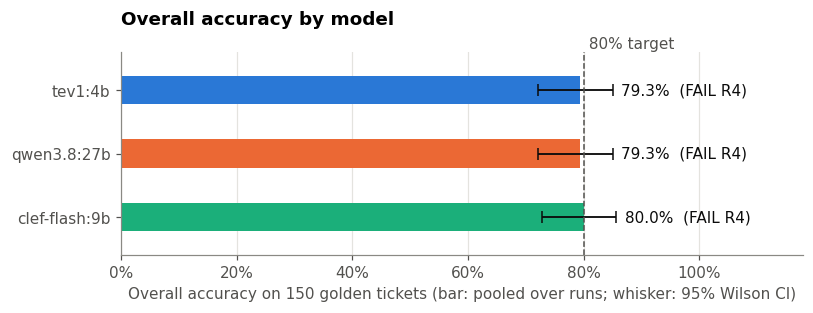

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 0.7 + 0.75 * len(MODELS)))
ys = np.arange(len(MODELS))[::-1]
for y, tag in zip(ys, MODELS):
    r = summary.set_index("model").loc[tag]
    if r.status == "pending":
        ax.text(0.01, y, "pending - no results yet", va="center", color="#8a8984", style="italic")
        continue
    ax.barh(y, r.accuracy, height=0.45, color=MODEL_COLORS[tag])
    ax.errorbar(r.accuracy, y, xerr=[[r.accuracy - r.ci95_low], [r.ci95_high - r.accuracy]],
                fmt="none", ecolor="#0b0b0b", elinewidth=1.2, capsize=4)
    ax.text(r.ci95_high + 0.015, y, f"{r.accuracy:.1%}  ({'PASS' if r.r4_all_runs else 'FAIL'} R4)",
            va="center", color="#0b0b0b")
ax.axvline(OVERALL_MIN, color="#52514e", linestyle="--", linewidth=1)
ax.text(OVERALL_MIN, 1.0, " 80% target", color="#52514e", va="bottom", transform=ax.get_xaxis_transform())
ax.set_ylim(-0.6, len(MODELS) - 0.4)
ax.set_yticks(ys, list(MODELS))
ax.set_xlim(0, 1.18)
ax.set_xticks(np.linspace(0, 1, 6), [f"{x:.0%}" for x in np.linspace(0, 1, 6)])
ax.grid(axis="y", visible=False)
ax.set_xlabel("Overall accuracy on 150 golden tickets (bar: pooled over runs; whisker: 95% Wilson CI)")
ax.set_title("Overall accuracy by model", loc="left", fontweight="bold", pad=18)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "accuracy_by_model.png"), bbox_inches="tight")
plt.show()


## 4. Recall per category

R4 needs ≥ 70% recall in each category, counted in tickets (for example Debt collection has only
8 golden tickets, so at least 6 must be correct). Cells show correct/total over all runs pooled.

In [6]:
need = golden.golden.value_counts().reindex(CATEGORIES).apply(lambda n: math.ceil(RECALL_MIN * n))
recall_tbl = pd.DataFrame(index=CATEGORIES)
recall_tbl["golden tickets"] = golden.golden.value_counts().reindex(CATEGORIES)
recall_tbl["needed (per run)"] = need
for tag in MODELS:
    keys = [k for k in runs if k[0] == tag]
    if not keys:
        recall_tbl[tag] = "pending"
        continue
    s = score(pd.concat([runs[k] for k in keys]))
    recall_tbl[tag] = [
        f"{got}/{n} = {got / n:.0%}" + ("" if got / n >= RECALL_MIN else "  below 70%")
        for got, n in (s["recall"][c] for c in CATEGORIES)
    ]
recall_tbl


,golden tickets,needed (per run),tev1:4b,qwen3.8:27b,clef-flash:9b
Credit reporting,38,27,36/38 = 95%,30/38 = 79%,37/38 = 97%
Debt collection,8,6,5/8 = 62% below 70%,7/8 = 88%,5/8 = 62% below 70%
Mortgage,19,14,18/19 = 95%,18/19 = 95%,17/19 = 89%
Credit card,16,12,14/16 = 88%,13/16 = 81%,14/16 = 88%
Bank account or service,39,28,26/39 = 67% below 70%,27/39 = 69% below 70%,23/39 = 59% below 70%
Consumer loan,14,10,6/14 = 43% below 70%,11/14 = 79%,9/14 = 64% below 70%
Money transfer or service,16,12,14/16 = 88%,13/16 = 81%,15/16 = 94%


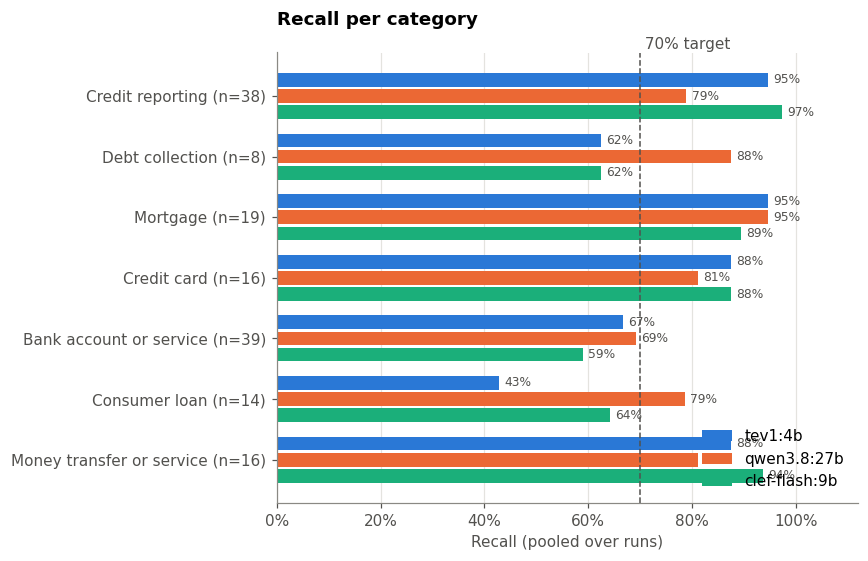

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.2))
n_models = max(len(available), 1)
height = 0.8 / n_models
ys = np.arange(len(CATEGORIES))[::-1]
for i, tag in enumerate(available):
    s = score(pd.concat([runs[k] for k in runs if k[0] == tag]))
    vals = [s["recall"][c][0] / s["recall"][c][1] for c in CATEGORIES]
    offs = ys + 0.4 - height * (i + 0.5)
    ax.barh(offs, vals, height=height * 0.85, color=MODEL_COLORS[tag], label=tag)
    for y, v in zip(offs, vals):
        ax.text(v + 0.01, y, f"{v:.0%}", va="center", fontsize=8, color="#52514e")
ax.axvline(RECALL_MIN, color="#52514e", linestyle="--", linewidth=1)
ax.text(RECALL_MIN, 1.0, " 70% target", color="#52514e", va="bottom", transform=ax.get_xaxis_transform())
ax.set_yticks(ys, [f"{c} (n={golden.golden.eq(c).sum()})" for c in CATEGORIES])
ax.set_xlim(0, 1.12)
ax.set_xticks(np.linspace(0, 1, 6), [f"{x:.0%}" for x in np.linspace(0, 1, 6)])
ax.grid(axis="y", visible=False)
ax.set_xlabel("Recall (pooled over runs)")
title = "Recall per category"
if pending:
    title += f"   (pending: {', '.join(pending)})"
ax.set_title(title, loc="left", fontweight="bold", pad=18)
if available:
    ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "recall_by_category.png"), bbox_inches="tight")
plt.show()


## 5. Confusion matrices

Rows are the golden label, columns the predicted category. Cells are the share of each golden
category's tickets (each row sums to 100%), pooled over runs, with the ticket count underneath.

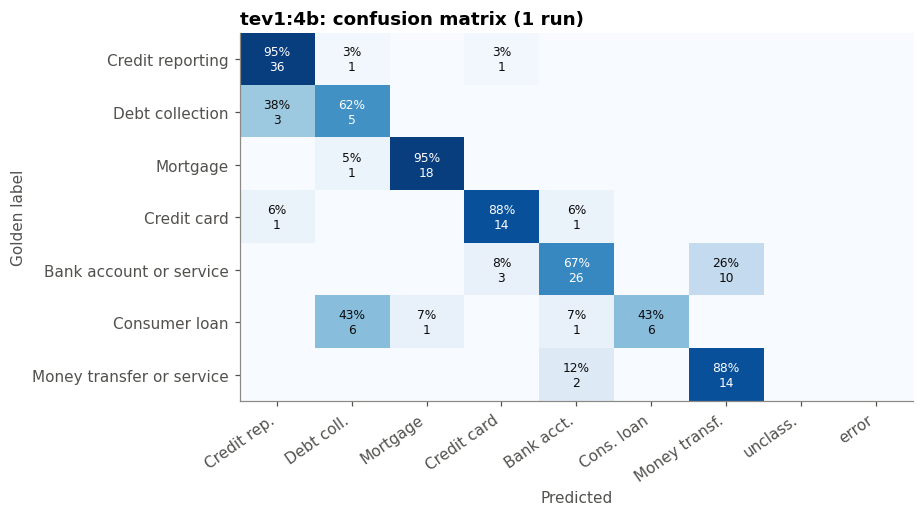

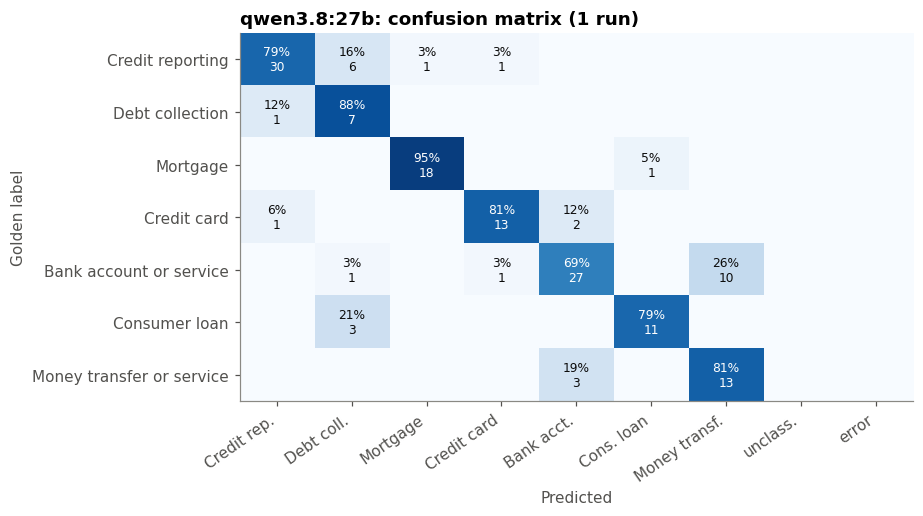

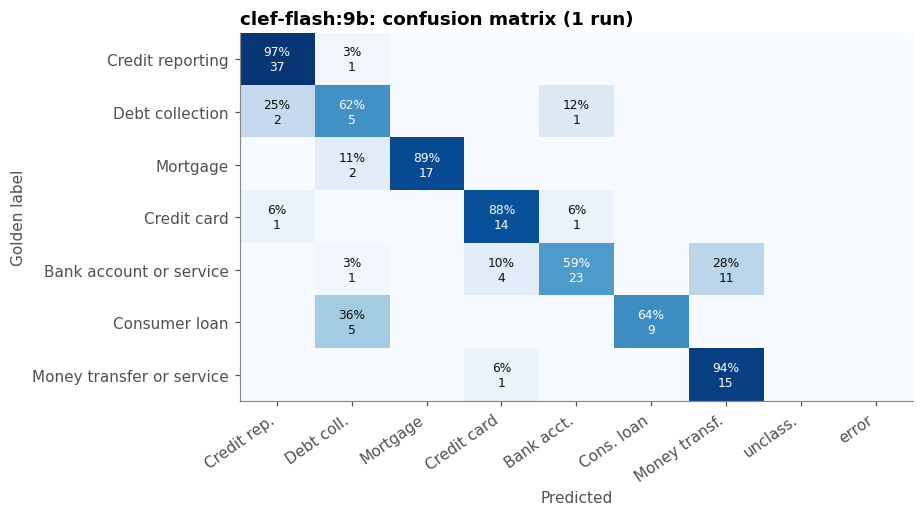

In [8]:
COLS = CATEGORIES + [UNCLASSIFIED, NO_RESPONSE]
short = {"Credit reporting": "Credit rep.", "Debt collection": "Debt coll.", "Mortgage": "Mortgage",
         "Credit card": "Credit card", "Bank account or service": "Bank acct.", "Consumer loan": "Cons. loan",
         "Money transfer or service": "Money transf.", UNCLASSIFIED: "unclass.", NO_RESPONSE: "error"}
confusions = {}
for tag in available:
    keys = [k for k in runs if k[0] == tag]
    pooled = pd.concat([runs[k] for k in keys])
    cm = pd.crosstab(pd.Categorical(pooled.golden, CATEGORIES), pd.Categorical(pooled.predicted, COLS), dropna=False)
    cm.index, cm.columns = CATEGORIES, COLS
    confusions[tag] = cm
    share = cm.div(cm.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.imshow(share.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(share.shape[0]):
        for j in range(share.shape[1]):
            if cm.iat[i, j]:
                v = share.iat[i, j]
                ax.text(j, i, f"{v:.0%}\n{cm.iat[i, j]}", ha="center", va="center", fontsize=8,
                        color="white" if v > 0.55 else "#0b0b0b")
    ax.set_xticks(range(len(COLS)), [short[c] for c in COLS], rotation=35, ha="right")
    ax.set_yticks(range(len(CATEGORIES)), CATEGORIES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Golden label")
    ax.grid(False)
    ax.set_title(f"{tag}: confusion matrix ({len(keys)} run{'s' if len(keys) > 1 else ''})", loc="left", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"confusion_{model_dir(tag)}.png"), bbox_inches="tight")
    plt.show()

for m in pending:
    print(f"{m}: pending, no confusion matrix yet")


### Most frequent confusions

In [9]:
rows = []
for tag in available:
    pooled = pd.concat([runs[k] for k in runs if k[0] == tag])
    wrong = pooled[~pooled.correct & (pooled.predicted != NO_RESPONSE)]
    for (g, p), c in wrong.groupby(["golden", "predicted"]).size().sort_values(ascending=False).head(6).items():
        rows.append({"model": tag, "golden": g, "predicted": p, "tickets": c})
pd.DataFrame(rows) if rows else Markdown("_No results yet._")


,model,golden,predicted,tickets
0,tev1:4b,Bank account or service,Money transfer or service,10
1,tev1:4b,Consumer loan,Debt collection,6
2,tev1:4b,Bank account or service,Credit card,3
3,tev1:4b,Debt collection,Credit reporting,3
4,tev1:4b,Money transfer or service,Bank account or service,2
5,tev1:4b,Consumer loan,Bank account or service,1
6,qwen3.8:27b,Bank account or service,Money transfer or service,10
7,qwen3.8:27b,Credit reporting,Debt collection,6
8,qwen3.8:27b,Money transfer or service,Bank account or service,3
9,qwen3.8:27b,Consumer loan,Debt collection,3


### Misclassified tickets

Every wrong prediction from the latest run of each model, with the start of the narrative, for
checking whether the error is the model's or a borderline golden label.

In [10]:
for tag in available:
    last = max((k for k in runs if k[0] == tag), key=lambda k: int(re.sub(r"\D", "", k[1])))
    wrong = runs[last][~runs[last].correct].merge(golden[["row", "narrative"]], on="row")
    wrong["narrative"] = wrong.narrative.str.slice(0, 160) + "..."
    display(Markdown(f"**{tag} {last}**: {len(wrong)} wrong"))
    display(wrong[["row", "golden", "predicted", "confidence", "narrative"]].reset_index(drop=True))


**tev1:4b ('tev1:4b', 'run1')**: 31 wrong

,row,golden,predicted,confidence,narrative
0,5737,Bank account or service,Credit card,0.672735,"On XX/XX/XXXX, I received a target email offer from AMEX for a {$500.00} cash bonus after opening a XXXX and deposit..."
1,5660,Bank account or service,Credit card,0.455520,"Randomly around XX/XX/XXXX or XXXX, my Klarna Debit card would not allow me to withdraw funds transfer funds or even..."
2,5626,Mortgage,Debt collection,0.565013,I entered a modification with Selene Finance in XX/XX/XXXX and never recieved any statements or tax documents for 2 ...
3,5636,Consumer loan,Debt collection,0.851884,MOHELA - Cash Loan : I am a cosigner. My daughter made a payment at 22 days past the due date on XXXX/XXXX/2016 via ...
4,5761,Bank account or service,Money transfer or service,0.691375,"I am filling a complaint against Cash App ( Block , INC . ) due to a inadequate customer service and unfair practice..."
5,5319,Consumer loan,Bank account or service,0.190603,XX/XX/XXXX I contacted Hyundai regarding getting the title and bill of sales after I was told by XXXX secretary of S...
6,5527,Bank account or service,Money transfer or service,0.663879,"I am submitting a complaint against Cash App ( Block , Inc. ) for inadequate customer service and unfair practices t..."
7,5235,Bank account or service,Money transfer or service,0.610307,Paypal is holding {$10.00} XXXX from my account they said that they can not release the money and I can not close th...
8,5986,Bank account or service,Money transfer or service,0.710365,"I am filling a complaint against Cash App ( Block , Inc ) due to inadequate customer service and unfair practices, w..."
9,5902,Debt collection,Credit reporting,0.625771,This is more info in reference to these complaints : XXXX XXXX I called XXXX XXXX XXXX ( Owned by XXXX XXXX ) and ...


**qwen3.8:27b ('qwen3.8:27b', 'run1')**: 31 wrong

,row,golden,predicted,confidence,narrative
0,5626,Mortgage,Consumer loan,None,I entered a modification with Selene Finance in XX/XX/XXXX and never recieved any statements or tax documents for 2 ...
1,5636,Consumer loan,Debt collection,None,MOHELA - Cash Loan : I am a cosigner. My daughter made a payment at 22 days past the due date on XXXX/XXXX/2016 via ...
2,5973,Credit reporting,Mortgage,None,Back XXXX i sent out a letter concerning payments with this mortgage company and they sent me out a letter stating t...
3,5761,Bank account or service,Money transfer or service,None,"I am filling a complaint against Cash App ( Block , INC . ) due to a inadequate customer service and unfair practice..."
4,5549,Credit reporting,Debt collection,None,The company Portfolio Recovery Associates has fraudulently placed their information against my social security numbe...
5,5174,Bank account or service,Debt collection,None,On XX/XX/XXXX I filed for Chapter XXXX Bankruptcy in the United States District Court of Minnesota. XXXX XXXX : XXXX...
6,5527,Bank account or service,Money transfer or service,None,"I am submitting a complaint against Cash App ( Block , Inc. ) for inadequate customer service and unfair practices t..."
7,5235,Bank account or service,Money transfer or service,None,Paypal is holding {$10.00} XXXX from my account they said that they can not release the money and I can not close th...
8,5101,Money transfer or service,Bank account or service,None,I paid 4 for Google play cards {$100.00} each I got scammed I guess and when I realized the scam stopped payment on ...
9,5986,Bank account or service,Money transfer or service,None,"I am filling a complaint against Cash App ( Block , Inc ) due to inadequate customer service and unfair practices, w..."


**clef-flash:9b ('clef-flash:9b', 'run1')**: 30 wrong

,row,golden,predicted,confidence,narrative
0,5737,Bank account or service,Credit card,0.796343,"On XX/XX/XXXX, I received a target email offer from AMEX for a {$500.00} cash bonus after opening a XXXX and deposit..."
1,5626,Mortgage,Debt collection,0.589074,I entered a modification with Selene Finance in XX/XX/XXXX and never recieved any statements or tax documents for 2 ...
2,5136,Mortgage,Debt collection,0.488369,"This Mortgage Company XXXX keeps harassing me over and over and over again AND KEEPS LEAVING ME VOICEMAILS, This jus..."
3,5636,Consumer loan,Debt collection,0.620209,MOHELA - Cash Loan : I am a cosigner. My daughter made a payment at 22 days past the due date on XXXX/XXXX/2016 via ...
4,5761,Bank account or service,Money transfer or service,0.812305,"I am filling a complaint against Cash App ( Block , INC . ) due to a inadequate customer service and unfair practice..."
5,5174,Bank account or service,Debt collection,0.528513,On XX/XX/XXXX I filed for Chapter XXXX Bankruptcy in the United States District Court of Minnesota. XXXX XXXX : XXXX...
6,5527,Bank account or service,Money transfer or service,0.836972,"I am submitting a complaint against Cash App ( Block , Inc. ) for inadequate customer service and unfair practices t..."
7,5235,Bank account or service,Money transfer or service,0.680713,Paypal is holding {$10.00} XXXX from my account they said that they can not release the money and I can not close th...
8,5986,Bank account or service,Money transfer or service,0.815189,"I am filling a complaint against Cash App ( Block , Inc ) due to inadequate customer service and unfair practices, w..."
9,5902,Debt collection,Credit reporting,0.432001,This is more info in reference to these complaints : XXXX XXXX I called XXXX XXXX XXXX ( Owned by XXXX XXXX ) and ...


## 6. Run-to-run consistency

For models with more than one run: the share of golden tickets that got the same prediction in every
run. Below 100% means the model is not deterministic for this prompt, so a single run's accuracy is
one sample of a spread.

In [11]:
rows = []
for tag in available:
    keys = [k for k in runs if k[0] == tag]
    if len(keys) < 2:
        rows.append({"model": tag, "runs": len(keys), "same prediction in every run": "needs 2+ runs"})
        continue
    wide = pd.concat({k[1]: runs[k].set_index("row").predicted for k in keys}, axis=1)
    rows.append({"model": tag, "runs": len(keys),
                 "same prediction in every run": f"{(wide.nunique(axis=1) == 1).mean():.1%}"})
for m in pending:
    rows.append({"model": m, "runs": 0, "same prediction in every run": "pending"})
pd.DataFrame(rows)


,model,runs,same prediction in every run
0,tev1:4b,1,needs 2+ runs
1,qwen3.8:27b,1,needs 2+ runs
2,clef-flash:9b,1,needs 2+ runs


## 7. Single-request latency and output tokens

Tickets are sent one at a time, so there is no queueing: this is each model's service time per
ticket. Percentiles use the nearest-rank method. `service` latency comes from the service log;
`client` (from `responses.csv`, used only when no log is available) also includes HTTP overhead.
`/v1/systemone` reports only token counts, which is why its output tokens are 1.

In [12]:
rows = []
for tag in MODELS:
    keys = [k for k in runs if k[0] == tag]
    if not keys:
        rows.append({"model": tag, "latency source": "pending"})
        continue
    pooled = pd.concat([runs[k] for k in keys])
    ok = pooled[pooled.predicted != NO_RESPONSE]
    lat = ok.latency_ms.dropna().tolist()
    tok = ok.output_tokens.dropna().tolist()
    rows.append({
        "model": tag,
        "latency source": ", ".join(sorted({run_meta[k]["latency_kind"] for k in keys})),
        "p50 (s)": nearest_rank(lat, 50) / 1000,
        "p95 (s)": nearest_rank(lat, 95) / 1000,
        "p99 (s)": nearest_rank(lat, 99) / 1000,
        "mean (s)": np.mean(lat) / 1000,
        "max (s)": max(lat) / 1000,
        "output tokens p50": nearest_rank(tok, 50) if tok else None,
        "output tokens max": max(tok) if tok else None,
    })
latency = pd.DataFrame(rows)
latency.round(2).fillna("-")


,model,latency source,p50 (s),p95 (s),p99 (s),mean (s),max (s),output tokens p50,output tokens max
0,tev1:4b,service,5.32,7.63,8.30,5.41,9.57,1,1
1,qwen3.8:27b,service,41.54,98.61,116.93,46.92,129.13,202,715
2,clef-flash:9b,service,9.49,13.23,14.49,9.73,15.48,0,0


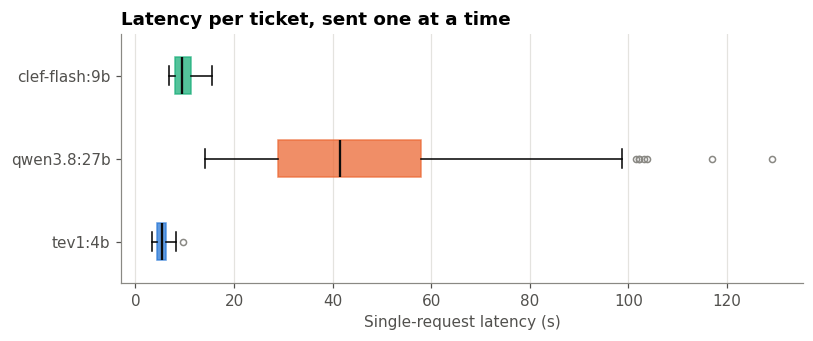

In [13]:
if available:
    fig, ax = plt.subplots(figsize=(7.5, 0.8 + 0.8 * len(available)))
    data = [pd.concat([runs[k] for k in runs if k[0] == tag]).query("predicted != @NO_RESPONSE").latency_ms.dropna() / 1000
            for tag in available]
    bp = ax.boxplot(data, vert=False, widths=0.45, patch_artist=True, showfliers=True,
                    medianprops={"color": "#0b0b0b", "linewidth": 1.5},
                    flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "none", "markeredgecolor": "#8a8984"})
    for patch, tag in zip(bp["boxes"], available):
        patch.set_facecolor(MODEL_COLORS[tag])
        patch.set_alpha(0.75)
        patch.set_edgecolor(MODEL_COLORS[tag])
    ax.set_yticks(range(1, len(available) + 1), available)
    ax.set_xlabel("Single-request latency (s)")
    ax.grid(axis="y", visible=False)
    title = "Latency per ticket, sent one at a time"
    if pending:
        title += f"   (pending: {', '.join(pending)})"
    ax.set_title(title, loc="left", fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "latency_by_model.png"), bbox_inches="tight")
    plt.show()


## 8. Save

Writes the tables and the per-ticket predictions to `test_and_measure/accuracy_output/` (the
charts above are saved there too).

In [14]:
summary.to_csv(os.path.join(OUT_DIR, "model_summary.csv"), index=False)
per_run.to_csv(os.path.join(OUT_DIR, "per_run.csv"), index=False)
recall_tbl.to_csv(os.path.join(OUT_DIR, "recall_by_category.csv"))
latency.to_csv(os.path.join(OUT_DIR, "latency.csv"), index=False)
if runs:
    pd.concat([p.assign(model=k[0], run=k[1]) for k, p in runs.items()]) \
        .to_csv(os.path.join(OUT_DIR, "predictions_all_runs.csv"), index=False)
for tag, cm in confusions.items():
    cm.to_csv(os.path.join(OUT_DIR, f"confusion_{model_dir(tag)}.csv"))
print("Saved to", os.path.relpath(OUT_DIR, ROOT))
print("Measured:", ", ".join(available) or "none", "| Pending:", ", ".join(pending) or "none")


Saved to test_and_measure\accuracy_output
Measured: tev1:4b, qwen3.8:27b, clef-flash:9b | Pending: none
